Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

Tarea 1

Obtener imagen en escala de grises

(512, 512)


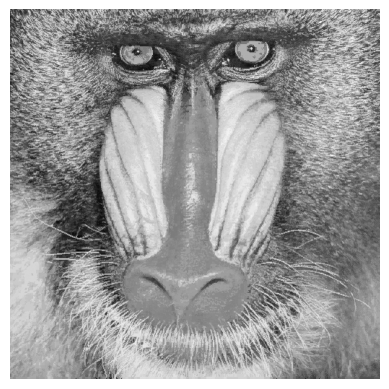

In [2]:
#Obtener imagen
img = cv2.imread('mandril.jpg')

#Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gris.shape)
#Muestra, indicando el mapa de color de grises con matplotlib
plt.figure()
#Eliminamos etiquetas de los ejes
plt.axis("off")
#Muestra la imagen en grises
plt.imshow(gris, cmap='gray') 
plt.show()

Obtener contornos con Canny

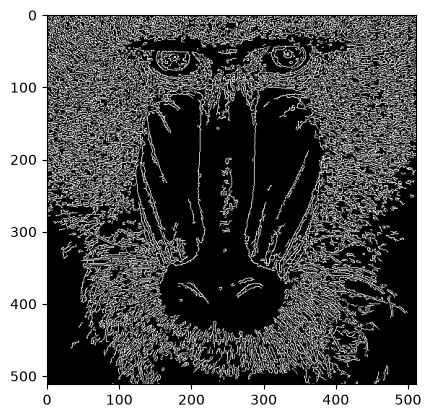

In [3]:
#Obtiene contornos con el operador de Canny
#Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 100, 200) #prueba a jugar con umbrales (entre 0 y 255)
#print(canny) #Muestra contenido, valores 0 o 255
#Visualiza resultado
plt.imshow(canny, cmap='gray') 
plt.show()

Conteo de píxeles blancos por filas

Valor máximo (maxfil): 0.4297
Umbral (0.90 * maxfil): 0.3867
Número de filas que cumplen la condición: 7
Posiciones de dichas filas: [  6  12  15  20  21  88 100]


(0.0, 512.0)

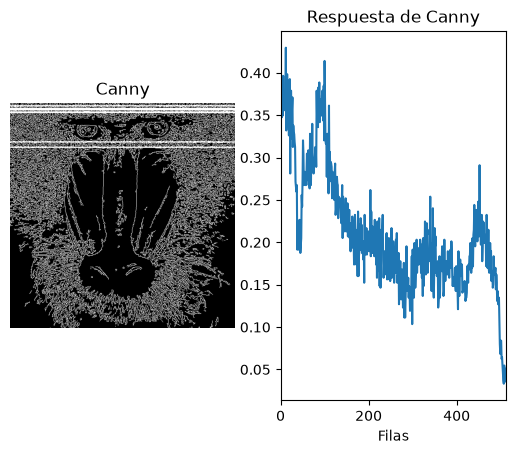

In [4]:
#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de columnas y el resultado será el número de píxeles blancos por fila
rows = row_counts[:, 0] / (255 * canny.shape[1])

maxfil = np.max(rows)
umbral = 0.9 * maxfil

max_rows = np.where(rows >= umbral)[0]

print(f"Valor máximo (maxfil): {maxfil:.4f}")
print(f"Umbral (0.90 * maxfil): {umbral:.4f}")
print(f"Número de filas que cumplen la condición: {len(max_rows)}")
print(f"Posiciones de dichas filas: {max_rows}")

# Define tipografías (Bastante limitadas en OpenCV)
font = cv2.FONT_HERSHEY_SIMPLEX

# Añadir líneas que resalten el umbral


for row in max_rows:
    cv2.line(canny, (0, row), (canny.shape[1] - 1, row), 255, 2)

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
#Rango en x definido por las filas
plt.xlim([0, canny.shape[1]])

Tarea 2

Obtener imagen con Sobel en 8 bits

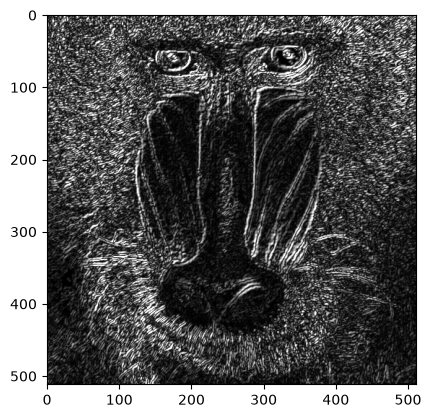

In [5]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

sobel8 = cv2.convertScaleAbs(sobel)

plt.imshow(sobel8, cmap='gray')

Se aplica el umbral a la imagen Sobel

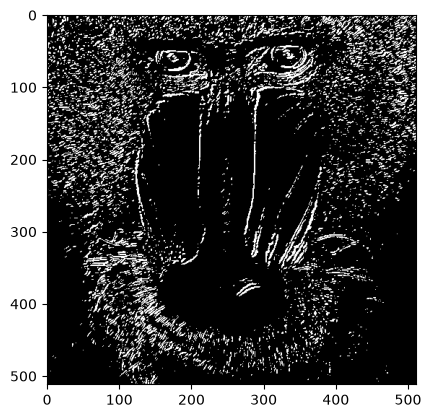

In [6]:
#Define valor umbral
valorUmbral = 130
#Obtiene imagen umbralizada para dicho valor definido
_, sobel8Umbral = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)
#Muestra resultado
plt.imshow(sobel8Umbral, cmap='gray')
plt.show()

Se aplica el umbral a la imagen Canny

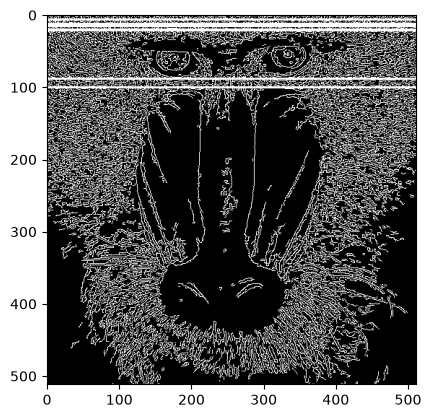

In [7]:
#Define valor umbral
valorUmbral = 130
#Obtiene imagen umbralizada para dicho valor definido
_, cannyUmbral = cv2.threshold(canny, valorUmbral, 255, cv2.THRESH_BINARY)
#Muestra resultado
plt.imshow(cannyUmbral, cmap='gray')
plt.show()

Ahora se realiza el conteo tanto por filas y columnas y se muestra la estadística para ambas imágenes umbralizadas

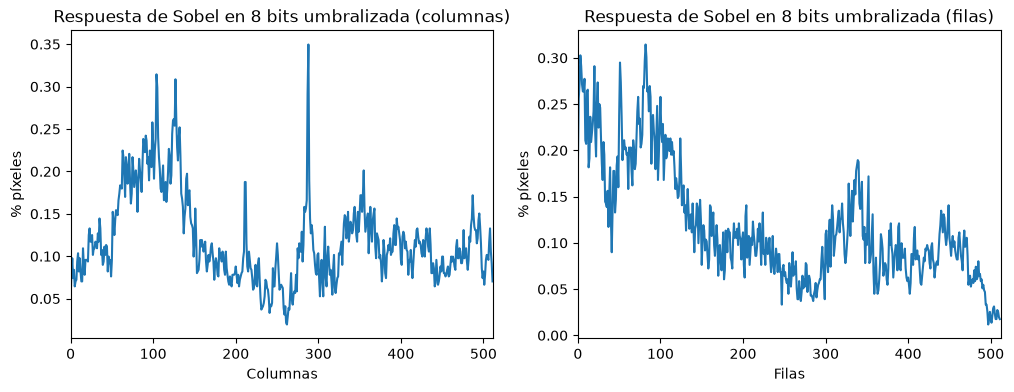

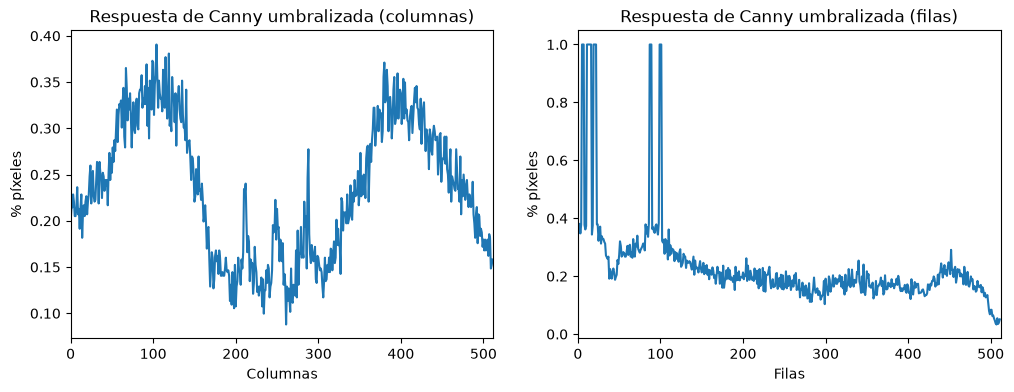

In [8]:
plt.figure(figsize=(12, 4))

# Sobel 8 bits umbralizado

# Columnas

col_counts = cv2.reduce(sobel8Umbral, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
sobel_cols = col_counts[0] / (255 * sobel8Umbral.shape[0])

plt.subplot(1, 2, 1)
plt.title("Respuesta de Sobel en 8 bits umbralizada (columnas)")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(sobel_cols)
plt.xlim([0, canny.shape[1]])

# Filas

row_counts = cv2.reduce(sobel8Umbral, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
sobel_rows = row_counts[:, 0] / (255 * sobel8Umbral.shape[1])

plt.subplot(1, 2, 2)
plt.title("Respuesta de Sobel en 8 bits umbralizada (filas)")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(sobel_rows)
plt.xlim([0, canny.shape[1]])
plt.show()

plt.figure(figsize=(12, 4))

# Canny umbralizado

# Columnas

col_counts = cv2.reduce(cannyUmbral, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
canny_cols = col_counts[0] / (255 * cannyUmbral.shape[0])

plt.subplot(1, 2, 1)
plt.title("Respuesta de Canny umbralizada (columnas)")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(canny_cols)
plt.xlim([0, canny.shape[1]])

# Filas

row_counts = cv2.reduce(cannyUmbral, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
canny_rows = row_counts[:, 0] / (255 * cannyUmbral.shape[1])

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny umbralizada (filas)")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(canny_rows)
plt.xlim([0, canny.shape[1]])
plt.show()

Se buscan los valores máximos por filas y columnas de ambas imágenes, mostrándolas en pantalla

SOBEL 8 BITS UMBRALIZADO

Valor máximo (maxfil): 0.3496
Umbral (0.90 * maxfil): 0.3146
Número de columnas que cumplen la condición: 1
Posiciones de dichas columnas: [288]
---------------------------
Valor máximo (maxfil): 0.3145
Umbral (0.90 * maxfil): 0.2830
Número de filas que cumplen la condición: 7
Posiciones de dichas filas: [ 3  4 20 51 81 82 83]
--------------------------------------------------------------
CANNY UMBRALIZADO

Valor máximo (maxfil): 0.3906
Umbral (0.90 * maxfil): 0.3516
Número de columnas que cumplen la condición: 21
Posiciones de dichas columnas: [ 67  86  92  96  99 100 103 104 105 107 112 115 119 123 135 379 380 383
 392 396 403]
---------------------------
Valor máximo (maxfil): 1.0000
Umbral (0.90 * maxfil): 0.9000
Número de filas que cumplen la condición: 19
Posiciones de dichas filas: [  5   6   7  11  12  13  14  15  16  19  20  21  22  87  88  89  99 100
 101]


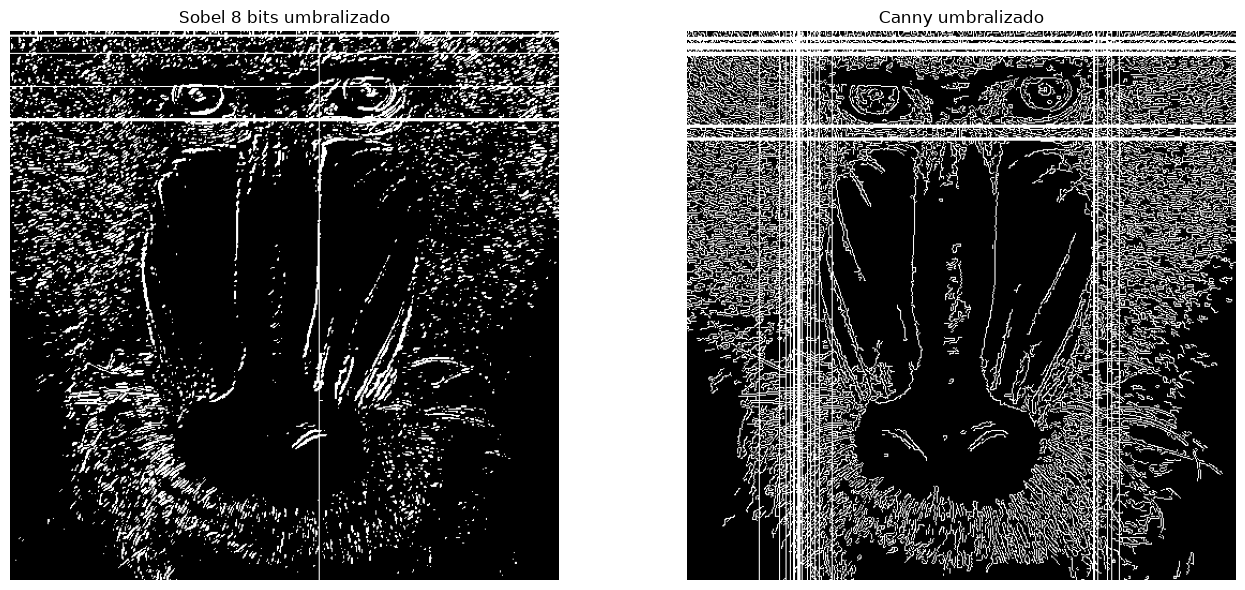

In [9]:
# Sobel 8 bits umbralizado

maxfil = np.max(sobel_cols)
umbral = 0.9 * maxfil

max_cols = np.where(sobel_cols >= umbral)[0]

print("SOBEL 8 BITS UMBRALIZADO")

print("")

print(f"Valor máximo (maxfil): {maxfil:.4f}")
print(f"Umbral (0.90 * maxfil): {umbral:.4f}")
print(f"Número de columnas que cumplen la condición: {len(max_cols)}")
print(f"Posiciones de dichas columnas: {max_cols}")

print("---------------------------")

maxfil = np.max(sobel_rows)
umbral = 0.9 * maxfil

max_rows = np.where(sobel_rows >= umbral)[0]

print(f"Valor máximo (maxfil): {maxfil:.4f}")
print(f"Umbral (0.90 * maxfil): {umbral:.4f}")
print(f"Número de filas que cumplen la condición: {len(max_rows)}")
print(f"Posiciones de dichas filas: {max_rows}")

for row in max_rows:
    cv2.line(sobel8Umbral, (0, row), (sobel8Umbral.shape[1] - 1, row), 255, 1)

for col in max_cols:
    cv2.line(sobel8Umbral, (col, 0), (col, sobel8Umbral.shape[0] - 1), 255, 1)


print("--------------------------------------------------------------")

# Canny umbralizado

print("CANNY UMBRALIZADO")

print("")

maxfil = np.max(canny_cols)
umbral = 0.9 * maxfil

max_cols = np.where(canny_cols >= umbral)[0]

print(f"Valor máximo (maxfil): {maxfil:.4f}")
print(f"Umbral (0.90 * maxfil): {umbral:.4f}")
print(f"Número de columnas que cumplen la condición: {len(max_cols)}")
print(f"Posiciones de dichas columnas: {max_cols}")

print("---------------------------")

maxfil = np.max(canny_rows)
umbral = 0.9 * maxfil

max_rows = np.where(canny_rows >= umbral)[0]

print(f"Valor máximo (maxfil): {maxfil:.4f}")
print(f"Umbral (0.90 * maxfil): {umbral:.4f}")
print(f"Número de filas que cumplen la condición: {len(max_rows)}")
print(f"Posiciones de dichas filas: {max_rows}")

for row in max_rows:
    cv2.line(cannyUmbral, (0, row), (cannyUmbral.shape[1] - 1, row), 255, 1)

for col in max_cols:
    cv2.line(cannyUmbral, (col, 0), (col, cannyUmbral.shape[0] - 1), 255, 1)

# Se muestran las imagenes

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.title("Sobel 8 bits umbralizado")
plt.imshow(sobel8Umbral, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Canny umbralizado")
plt.imshow(cannyUmbral, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

Tarea 3

In [ ]:
#Cortina de privacidad con Canny
vid = cv2.VideoCapture(0)

fondo = None         # Fondo (se actualiza poco a poco)
pos = None           # Posición actual de la cortina (columna)
vel_max = 25         # Máximo de píxeles que se mueve la cortina por fotograma
ancho_cortina = 160  # Ancho de la cortina en píxeles
n = 0                # Contador de fotogramas

while True:
    ret, frame = vid.read()
    if not ret:
        break
    n += 1

    # Conversión a grises y suavizado para reducir ruido
    gris = cv2.GaussianBlur(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), (5, 5), 0)

    # Diferencia con el fondo para obtener el movimiento
    if fondo is None:
        fondo = np.float32(gris)
    dif = cv2.absdiff(gris, cv2.convertScaleAbs(fondo))

    # El fondo se adapta a la escena: rápido al principio y lento después.
    # De esta forma no dejan "fantasmas".
    cv2.accumulateWeighted(gris, fondo, 0.3 if n < 30 else 0.05)

    # Umbraliza la diferencia
    _, mascara = cv2.threshold(dif, 25, 255, cv2.THRESH_BINARY)

    # Contornos con Canny sobre la máscara
    canny = cv2.Canny(mascara, 100, 200)

    # Conteo de píxeles blancos por columnas
    col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
    cols = col_counts[0] / (255 * canny.shape[0])

    # El objetivo es el centro de las columnas con contornos
    if n > 30 and cols.sum() > 0:
        objetivo = np.average(np.arange(len(cols)), weights=cols)
        pos = objetivo if pos is None else pos + np.clip(objetivo - pos, -vel_max, vel_max)

    # Dibuja la cortina
    if pos is not None:
        x0 = int(max(pos - ancho_cortina // 2, 0))
        x1 = int(min(pos + ancho_cortina // 2, frame.shape[1] - 1))
        cv2.rectangle(frame, (x0, 0), (x1, frame.shape[0]), (30, 30, 150), -1)
        for x in range(x0, x1, 10):
            cv2.line(frame, (x, 0), (x, frame.shape[0]), (60, 60, 110), 2)

    cv2.imshow('Cortina de privacidad', frame)
    cv2.imshow('Canny', canny)

    # Detener pulsando ESC
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()